# Multi-dimentional data set:

In [112]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [113]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [114]:
x , y = make_regression(n_samples=500, n_features=10, noise=0.1)

In [115]:
print(x.shape, y.shape)

(500, 10) (500,)


In [116]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.35)

In [117]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(325, 10) (325,)
(175, 10) (175,)


In [118]:
def gausian_nd(x, center=0, eps=1):
    return np.exp(-eps*np.linalg.norm(x-center)**2)

In [119]:
m = 100
centers =[]
eps = 0.5

for j in range(m):
    centers.append(np.random.uniform(x_train.min(axis=0),
                  x_train.max(axis=0)))

In [120]:
phi = np.zeros((y_train.shape[0], m))

for i in range(phi.shape[0]):
    for j in range(phi.shape[1]):
        phi[i, j] = gausian_nd(x_train[i, :], center=centers[j], eps=eps)

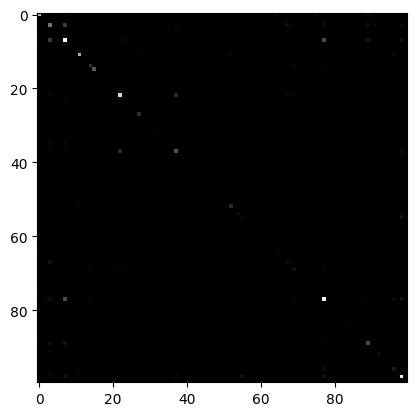

In [121]:
plt.imshow(phi.T@phi, cmap='gray');

In [122]:
l = np.linalg.inv(phi.T@phi)@phi.T@y_train

In [123]:
y_pred = []

for i in range(x_test.shape[0]):
    pred = 0
    for j in range(m):
        pred += l[j] * gausian_nd(x[i, :], center=centers[j], eps=eps)
    y_pred.append(pred)

y_pred = np.asarray(y_pred)

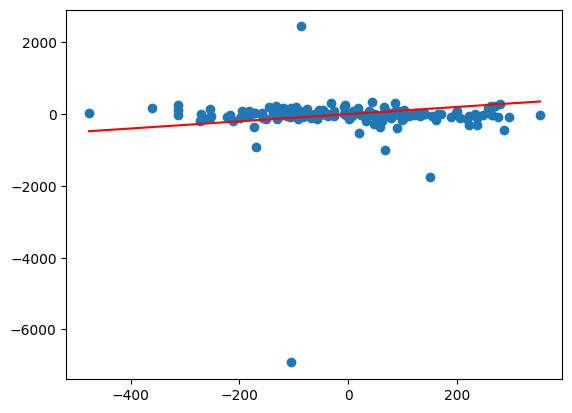

In [124]:
plt.scatter(y_test, y_pred)
plt.plot(np.linspace(y_test.min(), y_test.max(), 100),
         np.linspace(y_test.min(), y_test.max(), 100), c='red');
